# Задание: Visits_Data — визиты и конверсия по группам A/B

1. Кумулятивное количество посетителей на каждую группу и на каждый день  
2. Конверсия по группам: orders / visitors (заказы из Orders_Data.csv)  
3. Визуализация конверсии по группам  
4. Визуализация относительного изменения конверсии группы B к группе A  
5. Проверка гипотезы о статистической значимости различий в конверсии (A vs B)

In [1]:
# Установить matplotlib (выполнить один раз при первом запуске)
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Загрузка данных (Visits_Data.csv и Orders_Data.csv — в папке с ноутбуком)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

visits = pd.read_csv("Visits_Data.csv")
orders = pd.read_csv("Orders_Data.csv")
visits["date"] = pd.to_datetime(visits["date"])
orders["date"] = pd.to_datetime(orders["date"])
visits = visits.sort_values(["group", "date"])
print(visits.head())

        date group  visitors
0 2024-07-01     A       221
2 2024-07-02     A       249
4 2024-07-03     A       391
6 2024-07-04     A       228
8 2024-07-05     A       379


In [3]:
# Задание 1: кумулятивное количество посетителей по группе и по дню
visits["visitors_cum_group"] = visits.groupby("group")["visitors"].cumsum()
daily = visits.groupby("date")["visitors"].sum().sort_index().cumsum().reset_index()
daily.columns = ["date", "visitors_cum_day"]
print("Кумулятива по группе:")
print(visits[["date", "group", "visitors", "visitors_cum_group"]].tail(6))
print("\nКумулятива по дням (всего):")
print(daily.tail())

Кумулятива по группе:
         date group  visitors  visitors_cum_group
51 2024-07-26     B       384                7668
53 2024-07-27     B       330                7998
55 2024-07-28     B       257                8255
57 2024-07-29     B       365                8620
59 2024-07-30     B       361                8981
61 2024-07-31     B       362                9343

Кумулятива по дням (всего):
         date  visitors_cum_day
26 2024-07-27             16023
27 2024-07-28             16480
28 2024-07-29             17168
29 2024-07-30             17743
30 2024-07-31             18493


In [4]:
# Задание 2: конверсия по группам (orders / visitors)
orders_count = orders.groupby("group").size()
visitors_total = visits.groupby("group")["visitors"].sum()
conversion = orders_count / visitors_total
print("Конверсия по группам:")
print(conversion)

Конверсия по группам:
group
A    0.057268
B    0.050947
dtype: float64


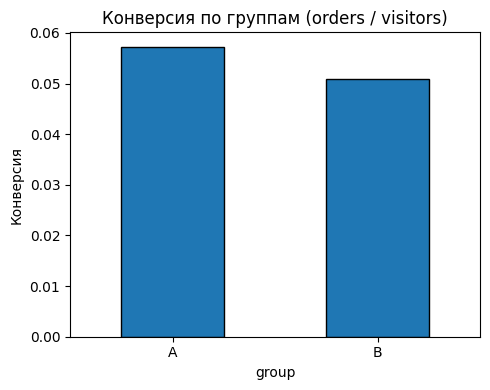

In [5]:
# Задание 3: визуализация конверсии по группам
conversion.plot(kind="bar", figsize=(5, 4), edgecolor="black")
plt.title("Конверсия по группам (orders / visitors)")
plt.ylabel("Конверсия")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Относительное изменение конверсии B к A: -11.04%


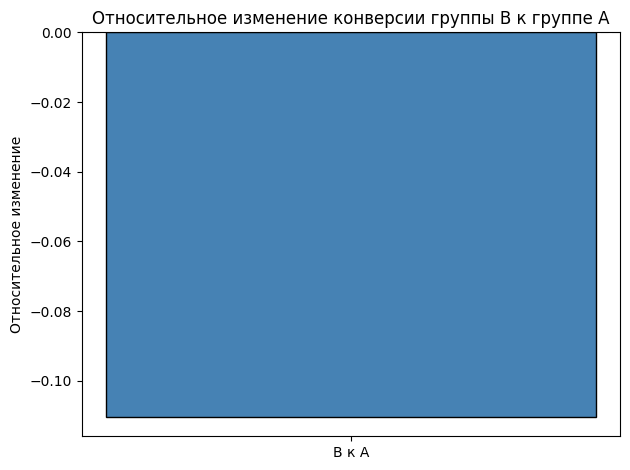

In [6]:
# Задание 4: относительное изменение конверсии B к A
conv_A, conv_B = conversion["A"], conversion["B"]
rel_change = (conv_B - conv_A) / conv_A
print(f"Относительное изменение конверсии B к A: {rel_change:.2%}")
plt.bar(["B к A"], [rel_change], color="steelblue", edgecolor="black")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Относительное изменение конверсии группы B к группе A")
plt.ylabel("Относительное изменение")
plt.tight_layout()
plt.show()

In [7]:
# Задание 5: гипотеза о статистической значимости различий в конверсии (A vs B)
# H0: конверсии в группах A и B равны. Проверка: критерий хи-квадрат по таблице сопряжённости
from scipy import stats

n_A, n_B = int(visitors_total["A"]), int(visitors_total["B"])
orders_A, orders_B = int(orders_count["A"]), int(orders_count["B"])
# Таблица: строки — группы A, B; столбцы — заказ (да / нет)
table = [[orders_A, n_A - orders_A], [orders_B, n_B - orders_B]]
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Таблица сопряжённости (заказы / без заказов):")
print(pd.DataFrame(table, index=["A", "B"], columns=["orders", "no_orders"]))
print(f"\nChi-square = {chi2:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Вывод: различия в конверсии статистически значимы (p < 0.05), H0 отвергаем.")
else:
    print("Вывод: статистически значимых различий нет (p >= 0.05), H0 не отвергаем.")

Таблица сопряжённости (заказы / без заказов):
   orders  no_orders
A     524       8626
B     476       8867

Chi-square = 3.4879, p-value = 0.0618
Вывод: статистически значимых различий нет (p >= 0.05), H0 не отвергаем.
